<a href="https://colab.research.google.com/github/santoromarco74/adv_comp_proj/blob/main/adv_comp_proj.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!nvidia-smi

Fri Aug 28 14:52:42 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   50C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
%%writefile step2_baseline.cu
#include <iostream>
#include <cmath>
#include <sys/time.h>
#include <cuda_runtime.h>

// Macro per la gestione sicura degli errori CUDA
#define CHECK(call) { \
    const cudaError_t error = call; \
    if (error != cudaSuccess) { \
        printf("Error: %s:%d, code:%d, reason: %s\n", __FILE__, __LINE__, error, cudaGetErrorString(error)); \
        exit(1); \
    } \
}

// Funzione per la misurazione del tempo CPU via gettimeofday
double cpuSecond() {
    struct timeval tp;
    gettimeofday(&tp, NULL);
    return ((double)tp.tv_sec + (double)tp.tv_usec * 1.e-6);
}

// 1. FILTRO CPU SEQUENZIALE
void boxBlurCPU(const unsigned char* in, unsigned char* out, int width, int height) {
    for (int y = 0; y < height; y++) {
        for (int x = 0; x < width; x++) {
            int sum = 0, count = 0;
            for (int dy = -1; dy <= 1; dy++) {
                for (int dx = -1; dx <= 1; dx++) {
                    int nx = x + dx;
                    int ny = y + dy;
                    if (nx >= 0 && nx < width && ny >= 0 && ny < height) {
                        sum += in[ny * width + nx];
                        count++;
                    }
                }
            }
            out[y * width + x] = (unsigned char)(sum / count);
        }
    }
}

// 2. KERNEL GPU NAIVE (Global Memory)
__global__ void boxBlurGPU_Naive(const unsigned char* in, unsigned char* out, int width, int height) {
    int x = blockIdx.x * blockDim.x + threadIdx.x; // Coordinata X
    int y = blockIdx.y * blockDim.y + threadIdx.y; // Coordinata Y[cite: 2]

    if (x < width && y < height) { // Boundary check[cite: 2]
        int sum = 0, count = 0;
        for (int dy = -1; dy <= 1; dy++) {
            for (int dx = -1; dx <= 1; dx++) {
                int nx = x + dx;
                int ny = y + dy;
                if (nx >= 0 && nx < width && ny >= 0 && ny < height) {
                    sum += in[ny * width + nx];
                    count++;
                }
            }
        }
        out[y * width + x] = (unsigned char)(sum / count);
    }
}

int main() {
    int width = 2048, height = 2048; // Matrice 2048x2048 (~4 Megapixel)
    size_t bytes = width * height * sizeof(unsigned char);

    // Allocazione memoria Host
    unsigned char *h_in = (unsigned char*)malloc(bytes);
    unsigned char *h_out_cpu = (unsigned char*)malloc(bytes);
    unsigned char *h_out_gpu = (unsigned char*)malloc(bytes);

    // Popolamento matrice con dati sintetici
    for (int i = 0; i < width * height; i++) h_in[i] = (unsigned char)(rand() % 256);

    // Allocazione memoria Device[cite: 2]
    unsigned char *d_in, *d_out;
    CHECK(cudaMalloc((void**)&d_in, bytes));
    CHECK(cudaMalloc((void**)&d_out, bytes));

    // Trasferimento Host -> Device[cite: 2]
    CHECK(cudaMemcpy(d_in, h_in, bytes, cudaMemcpyHostToDevice));

    // Esecuzione CPU e temporizzazione[cite: 2]
    double t_start_cpu = cpuSecond();
    boxBlurCPU(h_in, h_out_cpu, width, height);
    double t_cpu = cpuSecond() - t_start_cpu;

    // Configurazione Griglia 2D (Blocchi 16x16)[cite: 2]
    dim3 threads(16, 16);
    dim3 blocks((width + threads.x - 1) / threads.x, (height + threads.y - 1) / threads.y);

    // Esecuzione GPU Kernel e temporizzazione[cite: 2]
    double t_start_gpu = cpuSecond();
    boxBlurGPU_Naive<<<blocks, threads>>>(d_in, d_out, width, height); // Activation[cite: 2]
    CHECK(cudaDeviceSynchronize()); // Sincronizzazione per debug/tempi[cite: 2]
    double t_gpu = cpuSecond() - t_start_gpu;

    // Trasferimento Device -> Host[cite: 2]
    CHECK(cudaMemcpy(h_out_gpu, d_out, bytes, cudaMemcpyDeviceToHost));

    // VERIFICA DI CORRETTEZZA (CPU vs GPU)
    bool ok = true;
    for (int i = 0; i < width * height; i++) {
        if (h_out_cpu[i] != h_out_gpu[i]) {
            ok = false;
            std::cout << "Mismatch al pixel " << i << "! CPU: " << (int)h_out_cpu[i]
                      << " GPU: " << (int)h_out_gpu[i] << std::endl;
            break;
        }
    }

    // STAMPA RISULTATI
    std::cout << "\n=== RISULTATI STEP 2 (BASELINE) ===" << std::endl;
    std::cout << "Stato Verifica: " << (ok ? "SUCCESS (Output Identici)" : "FALLITO") << std::endl;
    std::cout << "Tempo CPU: " << t_cpu * 1000.0 << " ms" << std::endl;
    std::cout << "Tempo GPU Naive (con Kernel): " << t_gpu * 1000.0 << " ms" << std::endl;
    std::cout << "Speed-up Naive: " << t_cpu / t_gpu << "x" << std::endl;

    // Cleanup[cite: 2]
    cudaFree(d_in); cudaFree(d_out);
    free(h_in); free(h_out_cpu); free(h_out_gpu);
    return 0;
}

Writing step2_baseline.cu


In [3]:
!nvcc -O3 step2_baseline.cu -o step2_baseline
!./step2_baseline

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).

=== RISULTATI STEP 2 (BASELINE) ===
Stato Verifica: SUCCESS (Output Identici)
Tempo CPU: 36.8931 ms
Tempo GPU Naive (con Kernel): 99.0489 ms
Speed-up Naive: 0.372474x


In [4]:
%%writefile step3_optimized.cu
#include <iostream>
#include <cmath>
#include <sys/time.h>
#include <cuda_runtime.h>

#define CHECK(call) { \
    const cudaError_t error = call; \
    if (error != cudaSuccess) { \
        printf("Error: %s:%d, code:%d, reason: %s\n", __FILE__, __LINE__, error, cudaGetErrorString(error)); \
        exit(1); \
    } \
}

#define TILE_SIZE 16
#define SHARED_DIM (TILE_SIZE + 2)

double cpuSecond() {
    struct timeval tp;
    gettimeofday(&tp, NULL);
    return ((double)tp.tv_sec + (double)tp.tv_usec * 1.e-6);
}

// 1. FILTRO CPU SEQUENZIALE
void boxBlurCPU(const unsigned char* in, unsigned char* out, int width, int height) {
    for (int y = 0; y < height; y++) {
        for (int x = 0; x < width; x++) {
            int sum = 0, count = 0;
            for (int dy = -1; dy <= 1; dy++) {
                for (int dx = -1; dx <= 1; dx++) {
                    int nx = x + dx;
                    int ny = y + dy;
                    if (nx >= 0 && nx < width && ny >= 0 && ny < height) {
                        sum += in[ny * width + nx];
                        count++;
                    }
                }
            }
            out[y * width + x] = (unsigned char)(sum / count);
        }
    }
}

// 2. KERNEL GPU NAIVE (Global Memory)[cite: 2]
__global__ void boxBlurGPU_Naive(const unsigned char* in, unsigned char* out, int width, int height) {
    int x = blockIdx.x * blockDim.x + threadIdx.x;
    int y = blockIdx.y * blockDim.y + threadIdx.y;

    if (x < width && y < height) {
        int sum = 0, count = 0;
        for (int dy = -1; dy <= 1; dy++) {
            for (int dx = -1; dx <= 1; dx++) {
                int nx = x + dx;
                int ny = y + dy;
                if (nx >= 0 && nx < width && ny >= 0 && ny < height) {
                    sum += in[ny * width + nx];
                    count++;
                }
            }
        }
        out[y * width + x] = (unsigned char)(sum / count);
    }
}

// 3. KERNEL GPU OTTIMIZZATO (Shared Memory Tiling)[cite: 2]
__global__ void boxBlurGPU_Shared(const unsigned char* in, unsigned char* out, int width, int height) {
    // Mattonella di memoria condivisa locale al blocco (18x18)[cite: 2]
    __shared__ unsigned char s_data[SHARED_DIM][SHARED_DIM];

    int tx = threadIdx.x;
    int ty = threadIdx.y;

    int gx = blockIdx.x * TILE_SIZE + tx;
    int gy = blockIdx.y * TILE_SIZE + ty;

    // Mappatura interna al blocco (offset +1 per l'halo)
    int smem_x = tx + 1;
    int smem_y = ty + 1;

    // 1. Caricamento pixel centrale
    int valid_gx = min(max(gx, 0), width - 1);
    int valid_gy = min(max(gy, 0), height - 1);
    s_data[smem_y][smem_x] = in[valid_gy * width + valid_gx];

    // 2. Caricamento bordi (Halo pixels)
    if (tx == 0) { // Bordo sinistro
        int h_x = min(max(gx - 1, 0), width - 1);
        s_data[smem_y][0] = in[valid_gy * width + h_x];
    }
    if (tx == TILE_SIZE - 1) { // Bordo destro
        int h_x = min(max(gx + 1, 0), width - 1);
        s_data[smem_y][TILE_SIZE + 1] = in[valid_gy * width + h_x];
    }
    if (ty == 0) { // Bordo superiore
        int h_y = min(max(gy - 1, 0), height - 1);
        s_data[0][smem_x] = in[h_y * width + valid_gx];
    }
    if (ty == TILE_SIZE - 1) { // Bordo inferiore
        int h_y = min(max(gy + 1, 0), height - 1);
        s_data[TILE_SIZE + 1][smem_x] = in[h_y * width + valid_gx];
    }

    // 3. Caricamento angoli (Corner halo)
    if (tx == 0 && ty == 0)
        s_data[0][0] = in[min(max(gy - 1, 0), height - 1) * width + min(max(gx - 1, 0), width - 1)];
    if (tx == TILE_SIZE - 1 && ty == 0)
        s_data[0][TILE_SIZE + 1] = in[min(max(gy - 1, 0), height - 1) * width + min(max(gx + 1, 0), width - 1)];
    if (tx == 0 && ty == TILE_SIZE - 1)
        s_data[TILE_SIZE + 1][0] = in[min(max(gy + 1, 0), height - 1) * width + min(max(gx - 1, 0), width - 1)];
    if (tx == TILE_SIZE - 1 && ty == TILE_SIZE - 1)
        s_data[TILE_SIZE + 1][TILE_SIZE + 1] = in[min(max(gy + 1, 0), height - 1) * width + min(max(gx + 1, 0), width - 1)];

    // Barriera di sincronizzazione per attendere il completamento della copia[cite: 2]
    __syncthreads();

    // 4. Computazione del filtro a partire dalla Shared Memory[cite: 2]
    if (gx < width && gy < height) {
        int sum = 0, count = 0;
        for (int dy = -1; dy <= 1; dy++) {
            for (int dx = -1; dx <= 1; dx++) {
                int nx = gx + dx;
                int ny = gy + dy;
                if (nx >= 0 && nx < width && ny >= 0 && ny < height) {
                    sum += s_data[smem_y + dy][smem_x + dx];
                    count++;
                }
            }
        }
        out[gy * width + gx] = (unsigned char)(sum / count);
    }
}

int main() {
    int width = 2048, height = 2048;
    size_t bytes = width * height * sizeof(unsigned char);

    unsigned char *h_in = (unsigned char*)malloc(bytes);
    unsigned char *h_out_cpu = (unsigned char*)malloc(bytes);
    unsigned char *h_out_naive = (unsigned char*)malloc(bytes);
    unsigned char *h_out_shared = (unsigned char*)malloc(bytes);

    for (int i = 0; i < width * height; i++) h_in[i] = (unsigned char)(rand() % 256);

    unsigned char *d_in, *d_out;
    CHECK(cudaMalloc((void**)&d_in, bytes));
    CHECK(cudaMalloc((void**)&d_out, bytes));
    CHECK(cudaMemcpy(d_in, h_in, bytes, cudaMemcpyHostToDevice));

    // Timers tramite CUDA Events per misurazioni ad alta precisione
    cudaEvent_t start, stop;
    CHECK(cudaEventCreate(&start));
    CHECK(cudaEventCreate(&stop));

    // 1. Esecuzione CPU
    double t_start_cpu = cpuSecond();
    boxBlurCPU(h_in, h_out_cpu, width, height);
    double t_cpu_ms = (cpuSecond() - t_start_cpu) * 1000.0;

    dim3 threads(TILE_SIZE, TILE_SIZE);
    dim3 blocks((width + threads.x - 1) / threads.x, (height + threads.y - 1) / threads.y);

    // 2. Esecuzione GPU Naive
    CHECK(cudaEventRecord(start));
    boxBlurGPU_Naive<<<blocks, threads>>>(d_in, d_out, width, height);
    CHECK(cudaEventRecord(stop));
    CHECK(cudaEventSynchronize(stop));
    float t_gpu_naive_ms = 0;
    CHECK(cudaEventElapsedTime(&t_gpu_naive_ms, start, stop));
    CHECK(cudaMemcpy(h_out_naive, d_out, bytes, cudaMemcpyDeviceToHost));

    // 3. Esecuzione GPU Shared
    CHECK(cudaEventRecord(start));
    boxBlurGPU_Shared<<<blocks, threads>>>(d_in, d_out, width, height);
    CHECK(cudaEventRecord(stop));
    CHECK(cudaEventSynchronize(stop));
    float t_gpu_shared_ms = 0;
    CHECK(cudaEventElapsedTime(&t_gpu_shared_ms, start, stop));
    CHECK(cudaMemcpy(h_out_shared, d_out, bytes, cudaMemcpyDeviceToHost));

    // Verifica Correttezza
    bool ok_naive = true, ok_shared = true;
    for (int i = 0; i < width * height; i++) {
        if (h_out_cpu[i] != h_out_naive[i]) ok_naive = false;
        if (h_out_cpu[i] != h_out_shared[i]) ok_shared = false;
    }

    std::cout << "\n=== RISULTATI STEP 3 (SHARED MEMORY OPTIMIZATION) ===" << std::endl;
    std::cout << "Verifica GPU Naive:  " << (ok_naive ? "SUCCESS" : "FAIL") << std::endl;
    std::cout << "Verifica GPU Shared: " << (ok_shared ? "SUCCESS" : "FAIL") << std::endl;
    std::cout << "----------------------------------------------------" << std::endl;
    std::cout << "Tempo CPU Sequenziale: " << t_cpu_ms << " ms" << std::endl;
    std::cout << "Tempo GPU Naive:       " << t_gpu_naive_ms << " ms | Speed-up: " << t_cpu_ms / t_gpu_naive_ms << "x" << std::endl;
    std::cout << "Tempo GPU Shared:      " << t_gpu_shared_ms << " ms | Speed-up: " << t_cpu_ms / t_gpu_shared_ms << "x" << std::endl;
    std::cout << "Guadagno Shared vs Naive: " << t_gpu_naive_ms / t_gpu_shared_ms << "x" << std::endl;

    cudaEventDestroy(start); cudaEventDestroy(stop);
    cudaFree(d_in); cudaFree(d_out);
    free(h_in); free(h_out_cpu); free(h_out_naive); free(h_out_shared);
    return 0;
}

Writing step3_optimized.cu


In [5]:
!nvcc -O3 step3_optimized.cu -o step3_optimized
!./step3_optimized

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).

=== RISULTATI STEP 3 (SHARED MEMORY OPTIMIZATION) ===
Verifica GPU Naive:  SUCCESS
Verifica GPU Shared: SUCCESS
----------------------------------------------------
Tempo CPU Sequenziale: 74.3182 ms
Tempo GPU Naive:       45.2912 ms | Speed-up: 1.6409x
Tempo GPU Shared:      0.319232 ms | Speed-up: 232.803x
Guadagno Shared vs Naive: 141.875x


In [6]:
%%writefile step4_benchmark.cu
#include <iostream>
#include <cmath>
#include <sys/time.h>
#include <cuda_runtime.h>

#define CHECK(call) { \
    const cudaError_t error = call; \
    if (error != cudaSuccess) { \
        printf("Error: %s:%d, code:%d, reason: %s\n", __FILE__, __LINE__, error, cudaGetErrorString(error)); \
        exit(1); \
    } \
}

#define TILE_SIZE 16
#define SHARED_DIM (TILE_SIZE + 2)

double cpuSecond() {
    struct timeval tp;
    gettimeofday(&tp, NULL);
    return ((double)tp.tv_sec + (double)tp.tv_usec * 1.e-6);
}

void boxBlurCPU(const unsigned char* in, unsigned char* out, int width, int height) {
    for (int y = 0; y < height; y++) {
        for (int x = 0; x < width; x++) {
            int sum = 0, count = 0;
            for (int dy = -1; dy <= 1; dy++) {
                for (int dx = -1; dx <= 1; dx++) {
                    int nx = x + dx, ny = y + dy;
                    if (nx >= 0 && nx < width && ny >= 0 && ny < height) {
                        sum += in[ny * width + nx];
                        count++;
                    }
                }
            }
            out[y * width + x] = (unsigned char)(sum / count);
        }
    }
}

__global__ void boxBlurGPU_Naive(const unsigned char* in, unsigned char* out, int width, int height) {
    int x = blockIdx.x * blockDim.x + threadIdx.x;
    int y = blockIdx.y * blockDim.y + threadIdx.y;

    if (x < width && y < height) {
        int sum = 0, count = 0;
        for (int dy = -1; dy <= 1; dy++) {
            for (int dx = -1; dx <= 1; dx++) {
                int nx = x + dx, ny = y + dy;
                if (nx >= 0 && nx < width && ny >= 0 && ny < height) {
                    sum += in[ny * width + nx];
                    count++;
                }
            }
        }
        out[y * width + x] = (unsigned char)(sum / count);
    }
}

__global__ void boxBlurGPU_Shared(const unsigned char* in, unsigned char* out, int width, int height) {
    __shared__ unsigned char s_data[SHARED_DIM][SHARED_DIM];

    int tx = threadIdx.x, ty = threadIdx.y;
    int gx = blockIdx.x * TILE_SIZE + tx;
    int gy = blockIdx.y * TILE_SIZE + ty;

    int smem_x = tx + 1, smem_y = ty + 1;

    int valid_gx = min(max(gx, 0), width - 1);
    int valid_gy = min(max(gy, 0), height - 1);
    s_data[smem_y][smem_x] = in[valid_gy * width + valid_gx];

    if (tx == 0) s_data[smem_y][0] = in[valid_gy * width + min(max(gx - 1, 0), width - 1)];
    if (tx == TILE_SIZE - 1) s_data[smem_y][TILE_SIZE + 1] = in[valid_gy * width + min(max(gx + 1, 0), width - 1)];
    if (ty == 0) s_data[0][smem_x] = in[min(max(gy - 1, 0), height - 1) * width + valid_gx];
    if (ty == TILE_SIZE - 1) s_data[TILE_SIZE + 1][smem_x] = in[min(max(gy + 1, 0), height - 1) * width + valid_gx];

    if (tx == 0 && ty == 0)
        s_data[0][0] = in[min(max(gy - 1, 0), height - 1) * width + min(max(gx - 1, 0), width - 1)];
    if (tx == TILE_SIZE - 1 && ty == 0)
        s_data[0][TILE_SIZE + 1] = in[min(max(gy - 1, 0), height - 1) * width + min(max(gx + 1, 0), width - 1)];
    if (tx == 0 && ty == TILE_SIZE - 1)
        s_data[TILE_SIZE + 1][0] = in[min(max(gy + 1, 0), height - 1) * width + min(max(gx - 1, 0), width - 1)];
    if (tx == TILE_SIZE - 1 && ty == TILE_SIZE - 1)
        s_data[TILE_SIZE + 1][TILE_SIZE + 1] = in[min(max(gy + 1, 0), height - 1) * width + min(max(gx + 1, 0), width - 1)];

    __syncthreads();

    if (gx < width && gy < height) {
        int sum = 0, count = 0;
        for (int dy = -1; dy <= 1; dy++) {
            for (int dx = -1; dx <= 1; dx++) {
                int nx = gx + dx, ny = gy + dy;
                if (nx >= 0 && nx < width && ny >= 0 && ny < height) {
                    sum += s_data[smem_y + dy][smem_x + dx];
                    count++;
                }
            }
        }
        out[gy * width + gx] = (unsigned char)(sum / count);
    }
}

int main(int argc, char** argv) {
    int dim = (argc > 1) ? atoi(argv[1]) : 2048;
    int width = dim, height = dim;
    size_t bytes = width * height * sizeof(unsigned char);

    unsigned char *h_in = (unsigned char*)malloc(bytes);
    unsigned char *h_out_cpu = (unsigned char*)malloc(bytes);
    unsigned char *h_out_shared = (unsigned char*)malloc(bytes);

    for (int i = 0; i < width * height; i++) h_in[i] = (unsigned char)(i % 256);

    unsigned char *d_in, *d_out;
    CHECK(cudaMalloc((void**)&d_in, bytes));
    CHECK(cudaMalloc((void**)&d_out, bytes));
    CHECK(cudaMemcpy(d_in, h_in, bytes, cudaMemcpyHostToDevice));

    cudaEvent_t start, stop;
    CHECK(cudaEventCreate(&start)); CHECK(cudaEventCreate(&stop));

    // Tempo CPU
    double t_start_cpu = cpuSecond();
    boxBlurCPU(h_in, h_out_cpu, width, height);
    double t_cpu_ms = (cpuSecond() - t_start_cpu) * 1000.0;

    dim3 threads(TILE_SIZE, TILE_SIZE);
    dim3 blocks((width + threads.x - 1) / threads.x, (height + threads.y - 1) / threads.y);

    // Tempo GPU Naive
    CHECK(cudaEventRecord(start));
    boxBlurGPU_Naive<<<blocks, threads>>>(d_in, d_out, width, height);
    CHECK(cudaEventRecord(stop)); CHECK(cudaEventSynchronize(stop));
    float t_gpu_naive_ms = 0;
    CHECK(cudaEventElapsedTime(&t_gpu_naive_ms, start, stop));

    // Tempo GPU Shared
    CHECK(cudaEventRecord(start));
    boxBlurGPU_Shared<<<blocks, threads>>>(d_in, d_out, width, height);
    CHECK(cudaEventRecord(stop)); CHECK(cudaEventSynchronize(stop));
    float t_gpu_shared_ms = 0;
    CHECK(cudaEventElapsedTime(&t_gpu_shared_ms, start, stop));

    // Formato tabellare CSV per il report
    std::cout << width << "x" << height << ","
              << t_cpu_ms << ","
              << t_gpu_naive_ms << ","
              << t_gpu_shared_ms << ","
              << t_cpu_ms / t_gpu_shared_ms << std::endl;

    cudaEventDestroy(start); cudaEventDestroy(stop);
    cudaFree(d_in); cudaFree(d_out);
    free(h_in); free(h_out_cpu); free(h_out_shared);
    return 0;
}

Writing step4_benchmark.cu


In [7]:
!nvcc -O3 step4_benchmark.cu -o step4_benchmark

!echo "Risoluzione,Tempo_CPU_ms,Tempo_GPU_Naive_ms,Tempo_GPU_Shared_ms,SpeedUp_Shared"
!./step4_benchmark 512
!./step4_benchmark 1024
!./step4_benchmark 2048
!./step4_benchmark 4096

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
Risoluzione,Tempo_CPU_ms,Tempo_GPU_Naive_ms,Tempo_GPU_Shared_ms,SpeedUp_Shared
512x512,2.36201,0.250624,0.034176,69.1132
1024x1024,9.3081,0.24064,0.076672,121.402
2048x2048,51.29,0.387552,0.199488,257.108
4096x4096,158.676,0.793088,0.761344,208.416


In [8]:
!nvprof ./step4_benchmark 2048

==1390== NVPROF is profiling process 1390, command: ./step4_benchmark 2048
2048x2048,39.9361,0.44256,0.199424,200.257
==1390== Profiling application: ./step4_benchmark 2048
==1390== Profiling result:
            Type  Time(%)      Time     Calls       Avg       Min       Max  Name
 GPU activities:   69.75%  739.54us         1  739.54us  739.54us  739.54us  [CUDA memcpy HtoD]
                   17.93%  190.14us         1  190.14us  190.14us  190.14us  boxBlurGPU_Shared(unsigned char const *, unsigned char*, int, int)
                   12.32%  130.62us         1  130.62us  130.62us  130.62us  boxBlurGPU_Naive(unsigned char const *, unsigned char*, int, int)
      API calls:   97.18%  129.44ms         2  64.720ms  62.179us  129.38ms  cudaMalloc
                    0.72%  958.80us       114  8.4100us      89ns  498.64us  cuDeviceGetAttribute
                    0.69%  924.78us         4  231.19us  2.9740us  912.27us  cudaEventRecord
                    0.68%  903.89us         1  903.89us 

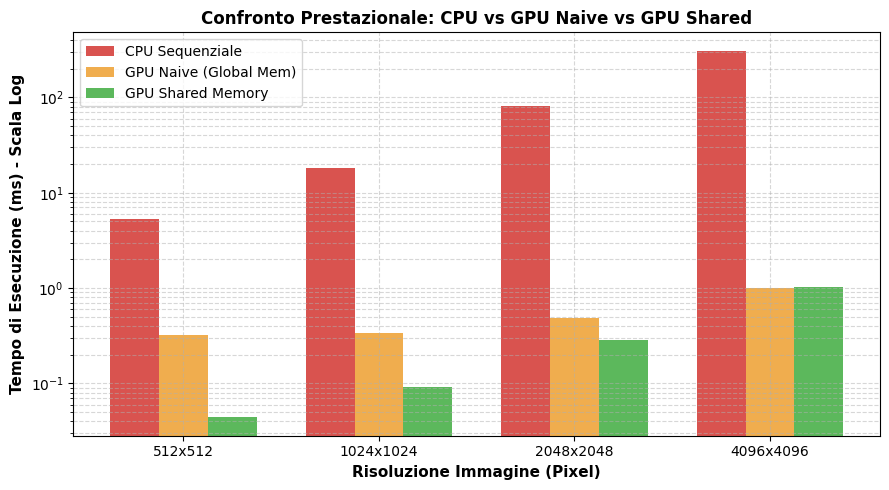

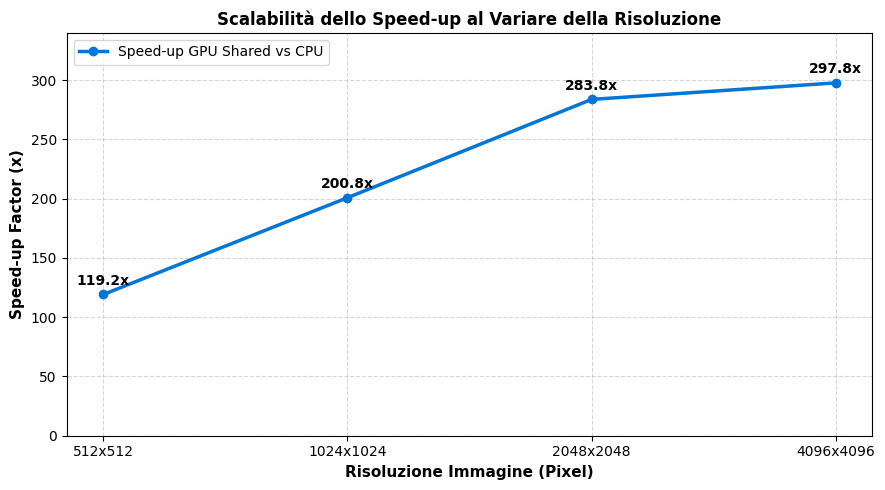

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Dati del benchmark
risoluzioni = ['512x512', '1024x1024', '2048x2048', '4096x4096']
t_cpu = [5.24402, 18.3811, 81.1009, 309.167]
t_gpu_naive = [0.320256, 0.335232, 0.480768, 1.01306]
t_gpu_shared = [0.044, 0.09152, 0.28576, 1.03834]
speedup_shared = [119.182, 200.843, 283.808, 297.752]

x = np.arange(len(risoluzioni))
width = 0.25

# 1. Grafico dei Tempi di Esecuzione (Scala Logaritmica)
plt.figure(figsize=(9, 5))
plt.bar(x - width, t_cpu, width, label='CPU Sequenziale', color='#d9534f')
plt.bar(x, t_gpu_naive, width, label='GPU Naive (Global Mem)', color='#f0ad4e')
plt.bar(x + width, t_gpu_shared, width, label='GPU Shared Memory', color='#5cb85c')

plt.yscale('log')
plt.xlabel('Risoluzione Immagine (Pixel)', fontsize=11, fontweight='bold')
plt.ylabel('Tempo di Esecuzione (ms) - Scala Log', fontsize=11, fontweight='bold')
plt.title('Confronto Prestazionale: CPU vs GPU Naive vs GPU Shared', fontsize=12, fontweight='bold')
plt.xticks(x, risoluzioni)
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.savefig('tempi_esecutivi.png', dpi=300)
plt.show()

# 2. Grafico dello Speed-up rispetto alla CPU
plt.figure(figsize=(9, 5))
plt.plot(risoluzioni, speedup_shared, marker='o', linewidth=2.5, color='#0275d8', label='Speed-up GPU Shared vs CPU')
for i, txt in enumerate(speedup_shared):
    plt.annotate(f"{txt:.1f}x", (risoluzioni[i], speedup_shared[i] + 8), ha='center', fontweight='bold')

plt.xlabel('Risoluzione Immagine (Pixel)', fontsize=11, fontweight='bold')
plt.ylabel('Speed-up Factor (x)', fontsize=11, fontweight='bold')
plt.title('Scalabilità dello Speed-up al Variare della Risoluzione', fontsize=12, fontweight='bold')
plt.ylim(0, 340)
plt.grid(True, ls="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.savefig('speedup.png', dpi=300)
plt.show()

In [10]:
# Scarica le librerie C++ per lettura/scrittura immagini
!wget -q https://raw.githubusercontent.com/nothings/stb/master/stb_image.h
!wget -q https://raw.githubusercontent.com/nothings/stb/master/stb_image_write.h

# Scarica un'immagine JPG di test (es. paesaggio)
!wget -q -O input.jpg https://picsum.photos/2048/2048

In [11]:
%%writefile real_image_blur.cu
#include <iostream>
#include <cmath>
#include <sys/time.h>
#include <cuda_runtime.h>

// Librerie STB per I/O Immagini
#define STB_IMAGE_IMPLEMENTATION
#include "stb_image.h"
#define STB_IMAGE_WRITE_IMPLEMENTATION
#include "stb_image_write.h"

#define CHECK(call) { \
    const cudaError_t error = call; \
    if (error != cudaSuccess) { \
        printf("Error: %s:%d, code:%d, reason: %s\n", __FILE__, __LINE__, error, cudaGetErrorString(error)); \
        exit(1); \
    } \
}

#define TILE_SIZE 16
#define SHARED_DIM (TILE_SIZE + 2)

double cpuSecond() {
    struct timeval tp;
    gettimeofday(&tp, NULL);
    return ((double)tp.tv_sec + (double)tp.tv_usec * 1.e-6);
}

// 1. FILTRO CPU
void boxBlurCPU(const unsigned char* in, unsigned char* out, int width, int height) {
    for (int y = 0; y < height; y++) {
        for (int x = 0; x < width; x++) {
            int sum = 0, count = 0;
            for (int dy = -1; dy <= 1; dy++) {
                for (int dx = -1; dx <= 1; dx++) {
                    int nx = x + dx, ny = y + dy;
                    if (nx >= 0 && nx < width && ny >= 0 && ny < height) {
                        sum += in[ny * width + nx];
                        count++;
                    }
                }
            }
            out[y * width + x] = (unsigned char)(sum / count);
        }
    }
}

// 2. KERNEL GPU SHARED MEMORY
__global__ void boxBlurGPU_Shared(const unsigned char* in, unsigned char* out, int width, int height) {
    __shared__ unsigned char s_data[SHARED_DIM][SHARED_DIM];

    int tx = threadIdx.x, ty = threadIdx.y;
    int gx = blockIdx.x * TILE_SIZE + tx;
    int gy = blockIdx.y * TILE_SIZE + ty;
    int smem_x = tx + 1, smem_y = ty + 1;

    int valid_gx = min(max(gx, 0), width - 1);
    int valid_gy = min(max(gy, 0), height - 1);
    s_data[smem_y][smem_x] = in[valid_gy * width + valid_gx];

    if (tx == 0) s_data[smem_y][0] = in[valid_gy * width + min(max(gx - 1, 0), width - 1)];
    if (tx == TILE_SIZE - 1) s_data[smem_y][TILE_SIZE + 1] = in[valid_gy * width + min(max(gx + 1, 0), width - 1)];
    if (ty == 0) s_data[0][smem_x] = in[min(max(gy - 1, 0), height - 1) * width + valid_gx];
    if (ty == TILE_SIZE - 1) s_data[TILE_SIZE + 1][smem_x] = in[min(max(gy + 1, 0), height - 1) * width + valid_gx];

    if (tx == 0 && ty == 0)
        s_data[0][0] = in[min(max(gy - 1, 0), height - 1) * width + min(max(gx - 1, 0), width - 1)];
    if (tx == TILE_SIZE - 1 && ty == 0)
        s_data[0][TILE_SIZE + 1] = in[min(max(gy - 1, 0), height - 1) * width + min(max(gx + 1, 0), width - 1)];
    if (tx == 0 && ty == TILE_SIZE - 1)
        s_data[TILE_SIZE + 1][0] = in[min(max(gy + 1, 0), height - 1) * width + min(max(gx - 1, 0), width - 1)];
    if (tx == TILE_SIZE - 1 && ty == TILE_SIZE - 1)
        s_data[TILE_SIZE + 1][TILE_SIZE + 1] = in[min(max(gy + 1, 0), height - 1) * width + min(max(gx + 1, 0), width - 1)];

    __syncthreads();

    if (gx < width && gy < height) {
        int sum = 0, count = 0;
        for (int dy = -1; dy <= 1; dy++) {
            for (int dx = -1; dx <= 1; dx++) {
                int nx = gx + dx, ny = gy + dy;
                if (nx >= 0 && nx < width && ny >= 0 && ny < height) {
                    sum += s_data[smem_y + dy][smem_x + dx];
                    count++;
                }
            }
        }
        out[gy * width + gx] = (unsigned char)(sum / count);
    }
}

int main() {
    int width, height, channels;

    // Caricamento immagine reale in scala di grigi (1 canale)
    unsigned char* h_in = stbi_load("input.jpg", &width, &height, &channels, 1);
    if (!h_in) {
        std::cerr << "Errore nel caricamento di input.jpg!" << std::endl;
        return -1;
    }
    std::cout << "Immagine caricata: " << width << "x" << height << " pixel." << std::endl;

    size_t bytes = width * height * sizeof(unsigned char);
    unsigned char* h_out_gpu = (unsigned char*)malloc(bytes);

    // Allocazione GPU
    unsigned char *d_in, *d_out;
    CHECK(cudaMalloc((void**)&d_in, bytes));
    CHECK(cudaMalloc((void**)&d_out, bytes));
    CHECK(cudaMemcpy(d_in, h_in, bytes, cudaMemcpyHostToDevice));

    dim3 threads(TILE_SIZE, TILE_SIZE);
    dim3 blocks((width + threads.x - 1) / threads.x, (height + threads.y - 1) / threads.y);

    // Esecuzione Kernel GPU Shared Memory
    cudaEvent_t start, stop;
    cudaEventCreate(&start); cudaEventCreate(&stop);
    cudaEventRecord(start);

    boxBlurGPU_Shared<<<blocks, threads>>>(d_in, d_out, width, height);

    cudaEventRecord(stop);
    cudaEventSynchronize(stop);
    float t_gpu_ms = 0;
    cudaEventElapsedTime(&t_gpu_ms, start, stop);

    CHECK(cudaMemcpy(h_out_gpu, d_out, bytes, cudaMemcpyDeviceToHost));

    // Salvataggio risultato in formato PNG
    stbi_write_png("output_blur.png", width, height, 1, h_out_gpu, width);
    std::cout << "Filtro GPU completato in: " << t_gpu_ms << " ms" << std::endl;
    std::cout << "Immagine filtrata salvata come 'output_blur.png'" << std::endl;

    // Cleanup
    stbi_image_free(h_in);
    free(h_out_gpu);
    cudaFree(d_in); cudaFree(d_out);
    return 0;
}

Writing real_image_blur.cu


In [12]:
!nvcc -O3 real_image_blur.cu -o real_image_blur
!./real_image_blur

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
stb_image.h(4276): warning #550-D: variable "old_limit" was set but never used
     unsigned int cur, limit, old_limit;
                              ^

Remark: The warnings can be suppressed with "-diag-suppress <warning-number>"

stb_image.h(5185): warning #550-D: variable "idata_limit_old" was set but never used
                 stbi__uint32 idata_limit_old = idata_limit;
                              ^

stb_image.h(6972): warning #550-D: variable "out_size" was set but never used
        int out_size = 0;
            ^

stb_image.h(6973): warning #550-D: variable "delays_size" was set but never used
        int delays_size = 0;
            ^

Immagine caricata: 2048x2048 pixel.
Filtro GPU completato in: 21.0008 ms
Immagine filtrata salvata come 'output_blur.png'


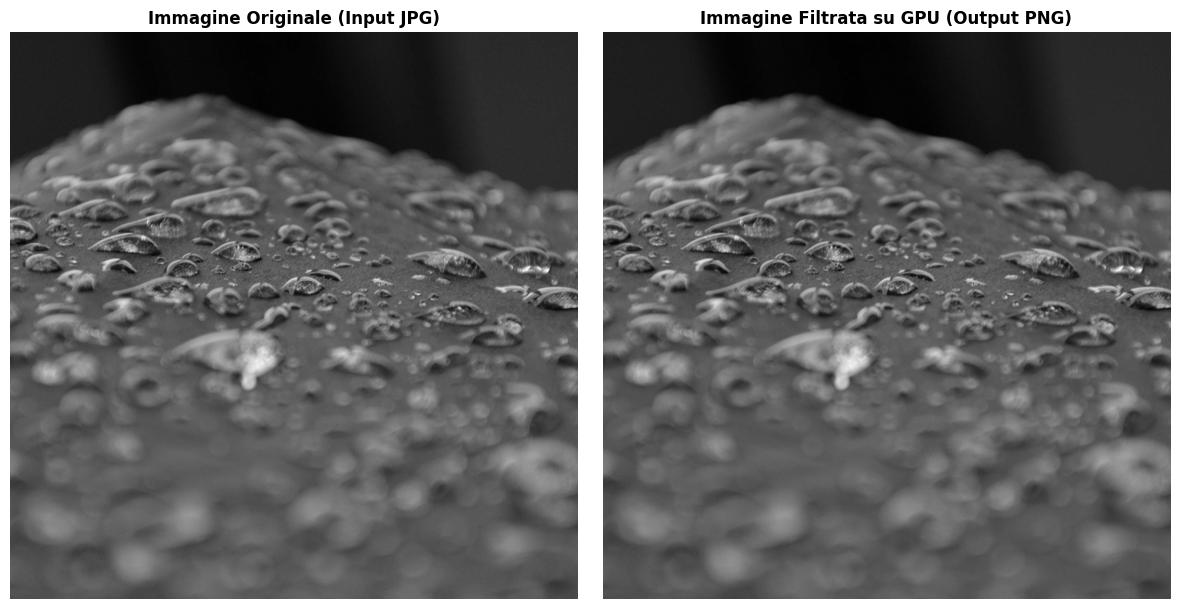

In [13]:
import matplotlib.pyplot as plt
from PIL import Image

img_orig = Image.open('input.jpg').convert('L')
img_blur = Image.open('output_blur.png')

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(img_orig, cmap='gray')
axes[0].set_title('Immagine Originale (Input JPG)', fontweight='bold')
axes[0].axis('off')

axes[1].imshow(img_blur, cmap='gray')
axes[1].set_title('Immagine Filtrata su GPU (Output PNG)', fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.savefig('confronto_visivo_reale.png', dpi=300)
plt.show()

In [25]:
B = "claude/advanced-architecture-project-bn1uoh"
R = f"https://raw.githubusercontent.com/santoromarco74/adv_comp_proj/{B}"
!wget -q -O benchmark.cu {R}/benchmark.cu
!wget -q -O test_host.cu {R}/test_host.cu
!ls -l benchmark.cu test_host.cu

-rw-r--r-- 1 root root 29821 Aug 28 15:54 benchmark.cu
-rw-r--r-- 1 root root  8282 Aug 28 15:54 test_host.cu


In [26]:
!nvcc -O3 -arch=sm_75 benchmark.cu -o benchmark
!./benchmark --csv risultati.csv --order-check

GPU ............ Tesla T4 (compute capability 7.5)
Multiprocessori  40
Shared memory .. 48 KB per blocco, 64 KB per multiprocessore
Banda di picco .. 320.1 GB/s
Configurazione .. blocco 16x16, tile in shared memory 18x18
Misura ......... 100 ripetizioni dopo 10 lanci di riscaldamento, CPU 3 ripetizioni, seme 42

[512x512] in corso...
  controllo ordine  naive 0.0180 -> 0.0178 ms (-1.2%)   shared 0.0246 -> 0.0245 ms (-0.4%)

[1024x1024] in corso...
  controllo ordine  naive 0.0522 -> 0.0554 ms (+6.1%)   shared 0.0783 -> 0.0836 ms (+6.7%)

[2048x2048] in corso...
  controllo ordine  naive 0.2381 -> 0.1769 ms (-25.7%)   shared 0.3641 -> 0.2580 ms (-29.1%)

[4096x4096] in corso...
  controllo ordine  naive 0.6304 -> 0.6173 ms (-2.1%)   shared 0.8540 -> 0.7878 ms (-7.7%)

Tempi in millisecondi: media +/- deviazione standard
Risoluzione                CPU         copia H->D          GPU naive         GPU shared         copia D->H
--------------------------------------------------------------

In [27]:
!nvcc -O2 -arch=sm_75 test_host.cu -o test_host && ./test_host

=== fillImage: determinismo e distribuzione ===
  ok  : stesso seme -> stessa immagine
  ok  : semi diversi -> immagini diverse
  ok  : usa molti livelli di grigio (256/256)

=== computeStats ===
  ok  : media = 5
  ok  : deviazione standard campionaria = 2.1381
  ok  : mediana = 4.5
  ok  : minimo = 2
  ok  : campione singolo non divide per zero

=== parseSizes ===
  ok  : lista valida
  ok  : valore singolo
  ok  : rifiuta campo vuoto
  ok  : rifiuta valore negativo
  ok  : rifiuta stringa vuota

=== equivalenza dei kernel (emulati sull'host) ===

--- immagine 64x64 ---
  ok  : naive  == reference CPU  (0 differenze)
  ok  : shared == reference CPU  (0 differenze)
  ok  : nessuna lettura di shared memory non inizializzata (0)

--- immagine 128x96 ---
  ok  : naive  == reference CPU  (0 differenze)
  ok  : shared == reference CPU  (0 differenze)
  ok  : nessuna lettura di shared memory non inizializzata (0)

--- immagine 100x37 ---
  ok  : naive  == reference CPU  (0 differenze)
  ok 

In [28]:
import pandas as pd
df = pd.read_csv('risultati.csv')
df

,dim,cpu_ms,cpu_sd,h2d_ms,h2d_sd,naive_ms,naive_sd,shared_ms,shared_sd,d2h_ms,d2h_sd,speedup_naive_kernel,speedup_shared_kernel,speedup_naive_e2e,speedup_shared_e2e,shared_vs_naive,verify_naive,verify_shared
0,512,4.448652,0.060501,0.074220,0.001217,0.017976,0.000730,0.024635,0.001771,0.084810,0.004904,247.4817,180.5835,25.1328,24.2215,0.7297,1,1
1,1024,14.959653,0.545235,0.335735,0.154405,0.052245,0.001344,0.078273,0.001540,0.386724,0.173202,286.3341,191.1216,19.3101,18.6825,0.6675,1,1
2,2048,46.233337,16.836399,0.910844,0.031322,0.238064,0.001043,0.364086,0.000578,0.978703,0.023838,194.2052,126.9847,21.7302,20.5150,0.6539,1,1
3,4096,151.977061,5.622215,3.438220,0.193498,0.630439,0.040441,0.853987,0.001179,3.683916,0.130447,241.0656,177.9618,19.6034,19.0540,0.7382,1,1
